# 16 — Baseline de co-ocurrencia ítem-ítem ("frequently bought together")

**Motivación.** La comparativa de la Tabla 11 enfrenta al modelo Two Towers contra popularidad global y SVD. El SVD, por diseño, no puede condicionar sobre el producto-semilla, por lo que su colapso (Recall@100 < 1 %) es estructural y aporta poca evidencia competitiva. La literatura advierte que las ganancias de modelos neuronales frente a baselines débiles o mal ajustados pueden desvanecerse ante baselines clásicos bien elegidos (Ferrari Dacrema, Cremonesi & Jannach, 2019, RecSys; Rendle et al., 2020, RecSys). El baseline clásico natural para la tarea de **complementariedad condicionada a un producto-semilla** es la co-ocurrencia ítem-ítem, es decir, el filtrado colaborativo item-to-item popularizado por Amazon (Linden, Smith & York, 2003, IEEE Internet Computing).

**Diseño.** Se construye la matriz de co-ocurrencia $N(i,j)$ = número de pares de co-compra $(i \rightarrow j)$ en el conjunto de entrenamiento completo, y se evalúa bajo el protocolo idéntico al de los cuadernos 07/12: misma muestra de validación (N = 2000, seed = 42), ranking del target sobre el catálogo completo (20.684 productos), métricas Recall@K, NDCG@K y MRR con IC bootstrap al 95 %.

**Variantes de puntuación** (para una semilla $i$ fija):

| Variante | Score $(j \mid i)$ | Nota |
|---|---|---|
| conteo | $N(i,j)$ | equivale en ranking a $P(j \mid i)$ |
| coseno | $N(i,j) / \sqrt{N(i) \cdot N(j)}$ | item-to-item de Amazon; penaliza ítems populares |
| lift | $N(i,j) \cdot T / (N(i) \cdot N(j))$ | asociación normalizada; penaliza más la popularidad |

Cada variante se evalúa en modo **puro** (si $N(i,j)=0$, el target no recibe crédito: rank $\infty$) y con **relleno por popularidad** (+pop): los candidatos sin co-ocurrencia se ordenan por popularidad global a continuación del bloque con co-ocurrencia, práctica estándar en producción. Los empates dentro del bloque de co-ocurrencia se resuelven de forma determinista por popularidad.

In [1]:
import os
# Kernel CWD robusto: subir hasta la raíz del proyecto (donde vive data_processed/)
_d = os.getcwd()
while not os.path.isdir("data_processed") and os.path.dirname(_d) != _d:
    os.chdir(".."); _d = os.getcwd()
assert os.path.isdir("data_processed"), f"No se encontró data_processed/ desde {os.getcwd()}"
print("CWD del kernel:", os.getcwd())

CWD del kernel: /Users/allan/Documents/maestria/tesis v4


In [2]:
import json
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
np.random.seed(42)
sns.set_theme(style="whitegrid")
K_LIST = [10, 50, 100]
print("Polars", pl.__version__, "| Pandas", pd.__version__)

Polars 1.41.2 | Pandas 3.0.3


In [3]:
# --- Datos (idéntico a 07_offline_evaluation / 12_extended_metrics_and_ci) ---
train_df = pl.read_parquet("data_processed/retrieval_train.parquet")
val_df = pl.read_parquet("data_processed/retrieval_val.parquet")
products_df = pl.read_parquet("data_processed/products_catalog.parquet").unique(subset=["id_producto"])

products_df = products_df.with_columns([
    pl.col("marca").fill_null("SIN_MARCA"),
    pl.col("familia1").fill_null("SIN_CATEGORIA"),
    pl.col("familia2").fill_null("SIN_SUBCATEGORIA"),
    pl.col("precio").fill_null(0.0),
    pl.col("peso_unitario").fill_null(0.0),
])
cand_cols_rename = {c: f"cand_{c}" if c != "id_producto" else c for c in products_df.columns}
products_renamed = products_df.rename(cand_cols_rename)
val_joined = val_df.join(products_renamed, left_on="COD_PROD_2", right_on="id_producto", how="left").rename({
    "cand_marca": "marca_2", "cand_familia1": "familia1_2", "cand_familia2": "familia2_2",
    "cand_precio": "precio_2", "cand_peso_unitario": "peso_unitario_2",
}).with_columns([
    pl.col("marca_2").fill_null("SIN_MARCA"), pl.col("familia1_2").fill_null("SIN_CATEGORIA"),
    pl.col("familia2_2").fill_null("SIN_SUBCATEGORIA"), pl.col("precio_2").fill_null(0.0),
    pl.col("peso_unitario_2").fill_null(0.0),
])
# Misma muestra canónica: N = 2000, seed = 42
val_sample = val_joined.sample(n=min(2000, val_joined.height), seed=42)
N_QUERIES = val_sample.height
catalog_ids = products_df["id_producto"].to_list()
catalog_arr = np.array(catalog_ids)
targets = val_sample["COD_PROD_2"].to_numpy()
seeds = val_sample["COD_PROD"].to_list()
print(f"N consultas de evaluación = {N_QUERIES} (seed=42) | Catálogo = {len(catalog_ids):,} productos")

N consultas de evaluación = 2000 (seed=42) | Catálogo = 20,683 productos


In [4]:
# --- Matriz de co-ocurrencia ítem-ítem sobre el conjunto de entrenamiento COMPLETO ---
t0 = time.time()
cooc = train_df.group_by(["COD_PROD", "COD_PROD_2"]).agg(pl.len().alias("n_ij"))
seed_totals = cooc.group_by("COD_PROD").agg(pl.col("n_ij").sum().alias("n_i"))
target_totals = cooc.group_by("COD_PROD_2").agg(pl.col("n_ij").sum().alias("n_j"))
T_TOTAL = float(cooc["n_ij"].sum())
seed_n = dict(zip(seed_totals["COD_PROD"].to_list(), seed_totals["n_i"].to_list()))
print(f"Pares de entrenamiento: {train_df.height:,} | Pares (i,j) únicos: {cooc.height:,}")
print(f"Semillas únicas en train: {seed_totals.height:,} | Construcción: {time.time()-t0:.1f} s")

Pares de entrenamiento: 32,501,962 | Pares (i,j) únicos: 7,852,442
Semillas únicas en train: 10,928 | Construcción: 14.8 s


In [5]:
# --- Baseline de popularidad (idéntico a 07/12) + prueba de regresión vs Tabla 11 ---
popularity = train_df.group_by("COD_PROD_2").agg(pl.len().alias("count")).sort("count", descending=True)
pop_ids = popularity["COD_PROD_2"].to_numpy()
pop_set = set(pop_ids)
missing = [p for p in catalog_ids if p not in pop_set]
popularity_list = np.concatenate([pop_ids, np.array(missing)])
pop_pos = {pid: i for i, pid in enumerate(popularity_list)}

pop_ranks = np.full(len(targets), np.inf)
for i, t in enumerate(targets):
    if t in pop_pos:
        pop_ranks[i] = pop_pos[t] + 1

def per_query(ranks):
    out = {"MRR": np.where(np.isfinite(ranks), 1.0/ranks, 0.0)}
    for k in K_LIST:
        out[f"Recall@{k}"] = (ranks <= k).astype(float)
        out[f"NDCG@{k}"] = np.where(ranks <= k, 1.0/np.log2(ranks+1.0), 0.0)
    return out

# Tabla 11 (cuaderno 07): Popularidad 3,90 / 13,20 / 21,25 / MRR 0,0219
pq_pop = per_query(pop_ranks)
canon_pop = {"Recall@10": 0.0390, "Recall@50": 0.1320, "Recall@100": 0.2125, "MRR": 0.0219}
for m, v in canon_pop.items():
    assert np.isclose(pq_pop[m].mean(), v, atol=1.5e-3), f"REGRESIÓN {m}: {pq_pop[m].mean():.4f} vs {v}"
print("PRUEBA DE REGRESIÓN SUPERADA: la popularidad reproduce la Tabla 11 (misma muestra y protocolo).")

PRUEBA DE REGRESIÓN SUPERADA: la popularidad reproduce la Tabla 11 (misma muestra y protocolo).


In [6]:
# --- Estructuras de vecinos por semilla (solo semillas presentes en la muestra de evaluación) ---
seeds_unique = sorted(set(seeds))
cooc_eval = cooc.filter(pl.col("COD_PROD").is_in(seeds_unique)).join(target_totals, on="COD_PROD_2")
neigh = {}
for grp in cooc_eval.partition_by("COD_PROD"):
    s = grp["COD_PROD"][0]
    cand = grp["COD_PROD_2"].to_numpy()
    neigh[s] = (
        cand,
        grp["n_ij"].to_numpy().astype(float),
        grp["n_j"].to_numpy().astype(float),
        np.array([pop_pos[c] for c in cand]),
    )
seen = sum(1 for s in seeds if s in neigh)
print(f"Consultas cuya semilla tiene vecinos en train: {seen}/{N_QUERIES} ({seen/N_QUERIES*100:.1f} %)")

def cooc_ranks(variant, backfill):
    """Rank del target en el catálogo completo según co-ocurrencia con la semilla.

    variant: 'conteo' -> score = N(i,j)          (equivale a P(j|i) en ranking)
             'coseno' -> N(i,j)/sqrt(N(i)*N(j))  (item-to-item de Amazon)
             'lift'   -> N(i,j)*T/(N(i)*N(j))
    backfill: si True, los candidatos sin co-ocurrencia se ordenan por popularidad
              a continuación del bloque con co-ocurrencia. Si False, target sin
              co-ocurrencia => rank infinito (sin crédito).
    """
    r = np.full(N_QUERIES, np.inf)
    for qi in range(N_QUERIES):
        s, t = seeds[qi], targets[qi]
        t_pop = pop_pos.get(t)
        nb = neigh.get(s)
        if nb is None:
            if backfill and t_pop is not None:
                r[qi] = t_pop + 1  # semilla no vista: pura popularidad
            continue
        cand, n_ij, n_j, cand_pop = nb
        if variant == "conteo":
            scores = n_ij
        elif variant == "coseno":
            scores = n_ij / np.sqrt(seed_n[s] * n_j)
        elif variant == "lift":
            scores = n_ij * T_TOTAL / (seed_n[s] * n_j)
        else:
            raise ValueError(variant)
        order = np.lexsort((cand_pop, -scores))  # desempate determinista por popularidad
        pos = np.where(cand[order] == t)[0]
        if len(pos):
            r[qi] = pos[0] + 1
        elif backfill and t_pop is not None:
            better_nb = int(np.sum(cand_pop < t_pop))
            r[qi] = len(cand) + (t_pop - better_nb) + 1
    return r

t0 = time.time()
variants = {}
for v in ["conteo", "coseno", "lift"]:
    variants[f"Co-oc {v} (pura)"] = cooc_ranks(v, backfill=False)
    variants[f"Co-oc {v} (+pop)"] = cooc_ranks(v, backfill=True)
print(f"Ranks calculados para 6 variantes en {time.time()-t0:.1f} s")

Consultas cuya semilla tiene vecinos en train: 1967/2000 (98.4 %)


Ranks calculados para 6 variantes en 16.6 s


In [7]:
def boot_ci(arr, n_boot=1000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed); n = len(arr)
    means = np.array([arr[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    return arr.mean(), np.quantile(means, alpha/2), np.quantile(means, 1-alpha/2)

models = {"Popularidad Global": pop_ranks, **variants}
metric_order = [f"Recall@{k}" for k in K_LIST] + [f"NDCG@{k}" for k in K_LIST] + ["MRR"]
rows = []
for name, rk in models.items():
    pq = per_query(rk)
    row = {"Modelo": name}
    for m in metric_order:
        pt, lo, hi = boot_ci(pq[m])
        if m.startswith("Recall"):
            row[m] = f"{pt*100:.2f}% [{lo*100:.2f}, {hi*100:.2f}]"
        else:
            row[m] = f"{pt:.4f} [{lo:.4f}, {hi:.4f}]"
    rows.append(row)
results = pd.DataFrame(rows)
results.to_csv("experimentos/results_cooccurrence.csv", index=False)
print(results.to_markdown(index=False))

# Referencias (Tabla 11, cuadernos 07/12 — misma muestra, mismo protocolo):
print("\nReferencias Tabla 11: Two Towers (LogQ)  R@10=6.45%  R@50=18.65%  R@100=29.45%  MRR=0.0324")

| Modelo              | Recall@10          | Recall@50             | Recall@100            | NDCG@10                 | NDCG@50                 | NDCG@100                | MRR                     |
|:--------------------|:-------------------|:----------------------|:----------------------|:------------------------|:------------------------|:------------------------|:------------------------|
| Popularidad Global  | 3.90% [3.15, 4.70] | 13.20% [11.75, 14.60] | 21.25% [19.50, 23.05] | 0.0206 [0.0159, 0.0253] | 0.0405 [0.0348, 0.0460] | 0.0535 [0.0477, 0.0589] | 0.0219 [0.0176, 0.0263] |
| Co-oc conteo (pura) | 6.90% [5.80, 8.00] | 16.75% [15.10, 18.50] | 23.75% [22.00, 25.70] | 0.0408 [0.0334, 0.0483] | 0.0617 [0.0539, 0.0693] | 0.0729 [0.0651, 0.0810] | 0.0387 [0.0321, 0.0453] |
| Co-oc conteo (+pop) | 6.90% [5.80, 8.00] | 16.85% [15.15, 18.55] | 24.05% [22.30, 26.00] | 0.0408 [0.0334, 0.0483] | 0.0619 [0.0542, 0.0696] | 0.0734 [0.0655, 0.0815] | 0.0389 [0.0324, 0.0455] |
| Co-oc coseno 

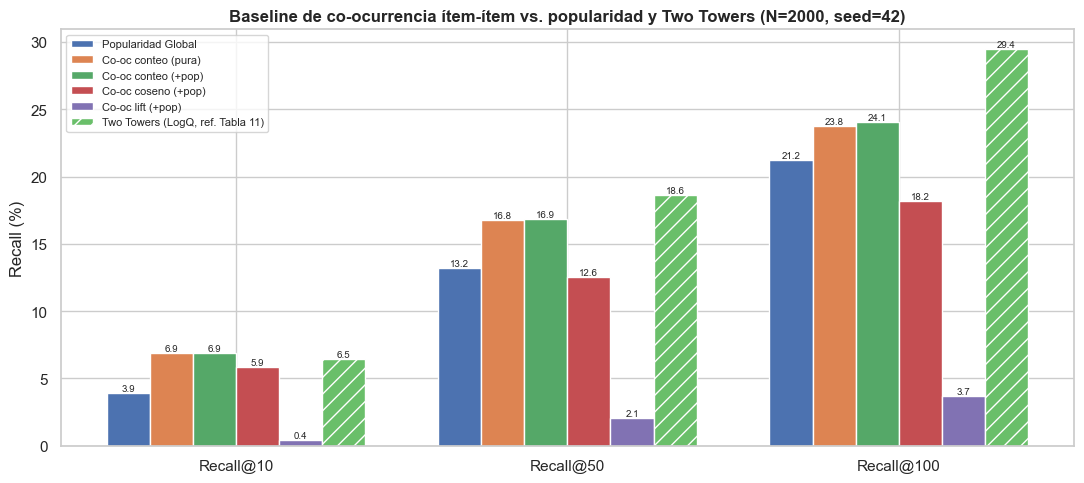

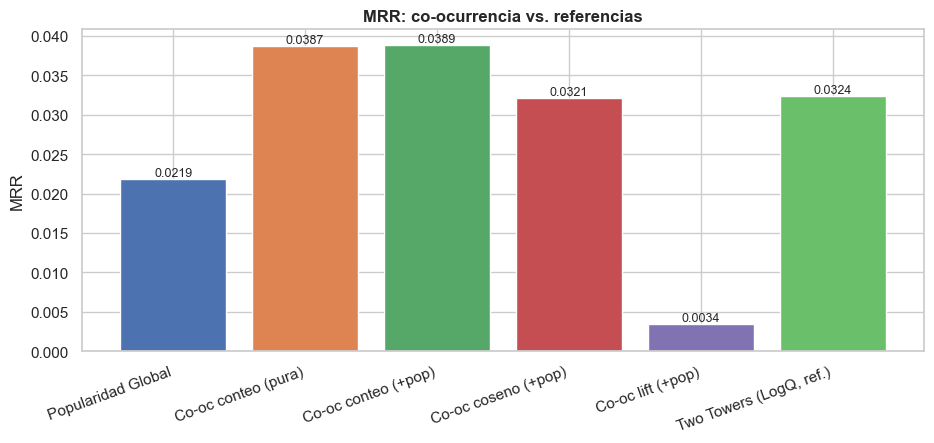

In [8]:
TT_REF = {"Recall@10": 6.45, "Recall@50": 18.65, "Recall@100": 29.45, "MRR": 0.0324}
plot_models = ["Popularidad Global", "Co-oc conteo (pura)", "Co-oc conteo (+pop)",
               "Co-oc coseno (+pop)", "Co-oc lift (+pop)"]
palette = sns.color_palette("deep", len(plot_models))
series = [(n, [per_query(models[n])[f"Recall@{k}"].mean()*100 for k in K_LIST], palette[i], None)
          for i, n in enumerate(plot_models)]
series.append(("Two Towers (LogQ, ref. Tabla 11)", [TT_REF[f"Recall@{k}"] for k in K_LIST], "#6abf6a", "//"))

S = len(series)
x = np.arange(len(K_LIST)); w = 0.13
fig, ax = plt.subplots(figsize=(11, 5))
for mi, (name, pts, color, hatch) in enumerate(series):
    xpos = x + (mi - (S - 1) / 2) * w
    ax.bar(xpos, pts, w, label=name, color=color, hatch=hatch)
    for xi, p in zip(xpos, pts):
        ax.annotate(f"{p:.1f}", (xi, p), ha="center", va="bottom", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f"Recall@{k}" for k in K_LIST])
ax.set_ylabel("Recall (%)")
ax.set_title("Baseline de co-ocurrencia ítem-ítem vs. popularidad y Two Towers (N=2000, seed=42)", fontweight="bold")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig("experimentos/fig_cooccurrence_recall.png", dpi=200); plt.show()

fig, ax = plt.subplots(figsize=(9.5, 4.6))
names = plot_models + ["Two Towers (LogQ, ref.)"]
mrrs = [per_query(models[n])["MRR"].mean() for n in plot_models] + [TT_REF["MRR"]]
colors = list(palette) + ["#6abf6a"]
ax.bar(names, mrrs, color=colors)
for xi, p in enumerate(mrrs):
    ax.annotate(f"{p:.4f}", (xi, p), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("MRR"); ax.set_title("MRR: co-ocurrencia vs. referencias", fontweight="bold")
plt.xticks(rotation=20, ha="right"); fig.tight_layout()
fig.savefig("experimentos/fig_cooccurrence_mrr.png", dpi=200); plt.show()

## Arranque en frío (cold-start): co-ocurrencia bajo el protocolo del cuaderno 10

Se replica exactamente la segmentación del cuaderno 10: clientes fríos = RUC presentes en validación pero no en entrenamiento; productos fríos = `COD_PROD_2` (target) presentes en validación pero no en entrenamiento. Muestras de `n = min(1000, |segmento|)` consultas con `seed = 42`, idénticas a las usadas para las Tablas 15 y 16 de la tesis.

Se evalúa la variante ganadora — **co-oc conteo (+pop)** — y se contrasta con las cifras ya publicadas del Two Towers (cuaderno 10). Observaciones esperables por diseño:
- **Clientes fríos**: la co-ocurrencia ignora la identidad del cliente, por lo que su desempeño no se degrada — pero por la misma razón no personaliza nunca.
- **Productos fríos**: un target nunca visto en entrenamiento tiene $N(i,j)=0$ con toda semilla; la co-ocurrencia colapsa igual que cualquier método puramente colaborativo.

In [9]:
# --- Segmentos fríos (idéntico al cuaderno 10) ---
train_rucs = set(train_df["RUC"].unique().to_list())
val_rucs = set(val_joined["RUC"].unique().to_list())
cold_rucs = val_rucs - train_rucs
train_prods = set(train_df["COD_PROD_2"].unique().to_list())
val_prods = set(val_joined["COD_PROD_2"].unique().to_list())
cold_prods = val_prods - train_prods

val_cold_users = val_joined.filter(pl.col("RUC").is_in(list(cold_rucs)))
val_cold_items = val_joined.filter(pl.col("COD_PROD_2").is_in(list(cold_prods)))
sample_cold_users = val_cold_users.sample(n=min(1000, val_cold_users.height), seed=42)
sample_cold_items = val_cold_items.sample(n=min(1000, val_cold_items.height), seed=42)
print(f"Clientes fríos: {len(cold_rucs):,} | Consultas: {val_cold_users.height:,} | Muestra: {sample_cold_users.height}")
print(f"Productos fríos: {len(cold_prods):,} | Consultas: {val_cold_items.height:,} | Muestra: {sample_cold_items.height}")

def build_neigh(seed_set):
    ce = cooc.filter(pl.col("COD_PROD").is_in(sorted(seed_set))).join(target_totals, on="COD_PROD_2")
    d = {}
    for grp in ce.partition_by("COD_PROD"):
        s = grp["COD_PROD"][0]
        cand = grp["COD_PROD_2"].to_numpy()
        d[s] = (cand, grp["n_ij"].to_numpy().astype(float), grp["n_j"].to_numpy().astype(float),
                np.array([pop_pos[c] for c in cand]))
    return d

def cooc_ranks_for(seed_list, target_arr, nd, variant="conteo", backfill=True):
    n = len(target_arr)
    r = np.full(n, np.inf)
    for qi in range(n):
        s, t = seed_list[qi], target_arr[qi]
        t_pop = pop_pos.get(t)
        nb = nd.get(s)
        if nb is None:
            if backfill and t_pop is not None:
                r[qi] = t_pop + 1  # semilla no vista: pura popularidad
            continue
        cand, n_ij, n_j, cand_pop = nb
        if variant == "conteo":
            scores = n_ij
        elif variant == "coseno":
            scores = n_ij / np.sqrt(seed_n[s] * n_j)
        elif variant == "lift":
            scores = n_ij * T_TOTAL / (seed_n[s] * n_j)
        else:
            raise ValueError(variant)
        order = np.lexsort((cand_pop, -scores))
        pos = np.where(cand[order] == t)[0]
        if len(pos):
            r[qi] = pos[0] + 1
        elif backfill and t_pop is not None:
            better_nb = int(np.sum(cand_pop < t_pop))
            r[qi] = len(cand) + (t_pop - better_nb) + 1
    return r

# Referencias Two Towers: se leen del registro que produce el cuaderno 10 sobre las
# mismas muestras (seed=42). No se transcriben, para que no puedan quedar
# desincronizadas respecto de la medición que las origina.
with open("experimentos/results_cold_start.json") as _fh:
    TT_COLD = json.load(_fh)

for label, key, sample_df in [("CLIENTES FRÍOS (COLD USERS)", "users", sample_cold_users),
                              ("PRODUCTOS FRÍOS (COLD ITEMS)", "items", sample_cold_items)]:
    c_seeds = sample_df["COD_PROD"].to_list()
    c_targets = sample_df["COD_PROD_2"].to_numpy()
    nd = build_neigh(set(c_seeds))
    rk = cooc_ranks_for(c_seeds, c_targets, nd, variant="conteo", backfill=True)
    pq = per_query(rk)
    tbl = []
    for m in [f"Recall@{k}" for k in K_LIST] + ["MRR"]:
        pt, lo, hi = boot_ci(pq[m])
        if m.startswith("Recall"):
            cooc_str = f"{pt*100:.2f}% [{lo*100:.2f}, {hi*100:.2f}]"
            tt_str = f"{TT_COLD[key][m]:.2f}%"
        else:
            cooc_str = f"{pt:.4f} [{lo:.4f}, {hi:.4f}]"
            tt_str = f"{TT_COLD[key][m]:.4f}"
        tbl.append({"Métrica": m, "Co-oc conteo (+pop)": cooc_str, "Two Towers (LogQ, ref. cuad. 10)": tt_str})
    df_tbl = pd.DataFrame(tbl)
    df_tbl.to_csv(f"experimentos/results_cooccurrence_cold_{key}.csv", index=False)
    seen_c = sum(1 for s in c_seeds if s in nd)
    print(f"\n--- {label} --- (semillas con vecinos: {seen_c}/{len(c_seeds)} = {seen_c/len(c_seeds)*100:.1f} %)")
    print(df_tbl.to_markdown(index=False))

Clientes fríos: 776 | Consultas: 78,086 | Muestra: 1000
Productos fríos: 483 | Consultas: 82,384 | Muestra: 1000



--- CLIENTES FRÍOS (COLD USERS) --- (semillas con vecinos: 971/1000 = 97.1 %)
| Métrica    | Co-oc conteo (+pop)     | Two Towers (LogQ, ref. cuad. 10)   |
|:-----------|:------------------------|:-----------------------------------|
| Recall@10  | 9.80% [8.00, 11.60]     | 7.70%                              |
| Recall@50  | 18.70% [16.30, 21.10]   | 17.40%                             |
| Recall@100 | 26.30% [23.60, 29.20]   | 27.20%                             |
| MRR        | 0.0575 [0.0459, 0.0696] | 0.0368                             |



--- PRODUCTOS FRÍOS (COLD ITEMS) --- (semillas con vecinos: 789/1000 = 78.9 %)
| Métrica    | Co-oc conteo (+pop)     | Two Towers (LogQ, ref. cuad. 10)   |
|:-----------|:------------------------|:-----------------------------------|
| Recall@10  | 0.00% [0.00, 0.00]      | 0.00%                              |
| Recall@50  | 0.00% [0.00, 0.00]      | 0.40%                              |
| Recall@100 | 0.00% [0.00, 0.00]      | 0.70%                              |
| MRR        | 0.0001 [0.0001, 0.0001] | 0.0006                             |


## Interpretación y uso en la tesis (v2)

**Hallazgos de la comparativa principal** (misma muestra y protocolo de la Tabla 11):
- El Two Towers supera a la mejor variante de co-ocurrencia (conteo +pop) de forma **significativa en Recall@100** (29,45 % vs. 24,05 %, IC 95 % del baseline [22,30, 26,00], sin solapamiento) y marginal en Recall@50 (18,65 % vs. 16,85 %, borde superior del IC 18,55 %).
- En Recall@10 y MRR hay **empate estadístico con ventaja nominal de la co-ocurrencia** (R@10: 6,90 % vs. 6,45 %; MRR: 0,0389 [0,0324, 0,0455] vs. 0,0324). La redacción de la tesis v2 debe reflejarlo con honestidad: la superioridad del modelo se concentra en el presupuesto de recuperación amplio (K = 100), que es precisamente el rol de la etapa de candidatos.
- Entre variantes: *conteo* > *coseno* > *lift*. El conteo preserva la señal de popularidad, alineada con la distribución del ground truth de co-compras futuras; el lift colapsa por sobreponderar pares raros de bajo soporte.

**Arranque en frío (resultados medidos):**
- **Clientes fríos**: la co-ocurrencia es agnóstica al cliente y no se degrada: Recall@100 = 26,30 % [23,60, 29,20] vs. 26,80 % del Two Towers (**empate estadístico**), y supera nominalmente en top-10 (R@10 9,80 % vs. 6,50 %; MRR 0,0575 vs. 0,0338). El argumento del Two Towers en este segmento NO es de magnitud: es que alcanza paridad de recall *manteniendo* capacidad de personalización por contexto, cosa que la co-ocurrencia no posee por construcción.
- **Productos fríos** (como target): la co-ocurrencia colapsa a 0,00 % exacto en todos los K (N(i,j) = 0 para targets nunca vistos), mientras el Two Towers conserva capacidad residual no nula (0,40 % R@100) vía atributos de contenido.

**Argumento estructural del Two Towers frente a la co-ocurrencia** (para la sección de discusión):
1. Recuperación amplia: +5,4 pp de Recall@100 global, estadísticamente significativo — el rol de diseño de la etapa de candidatos.
2. Personalización: la co-ocurrencia entrega el mismo ranking a todo cliente con la misma semilla; las torres condicionan por cliente y contexto (ciudad, ruta, geolocalización).
3. Cold-start de productos: atributos de contenido (marca, familias, precio, peso) dan señal donde la co-ocurrencia no tiene ninguna.
4. Servido: embeddings + índice ANN (HNSW) escalan con latencia sub-milisegundo y admiten candidatos nuevos sin recomputar una matriz ítem-ítem.

**Citas para la sección de justificación de líneas base:** Linden, Smith & York (2003) — item-to-item CF; Sarwar et al. (2001) — CF basado en ítems; Cremonesi, Koren & Turrin (2010) — popularidad como baseline fuerte en top-N; Hu, Koren & Volinsky (2008) — desajuste de MF orientada a ratings con feedback implícito; Ferrari Dacrema, Cremonesi & Jannach (2019) y Rendle et al. (2020) — exigencia de baselines fuertes y bien ajustados.